<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/modelado_clima_nino_colombia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Indicadores de Impacto del Fenómeno de El Niño ---
             region  total_registros  prom_deficit_lluvias  \
0     Región Andina               64                 54.01   
1   Región Pacífica               87                 52.72   
2     Región Caribe               90                 51.18   
3  Región Orinoquía               79                 50.47   

   prom_vulnerabilidad  total_hectareas_riesgo  
0                 5.54                 86191.0  
1                 5.50                133864.0  
2                 5.38                118443.0  
3                 6.00                 93207.0  


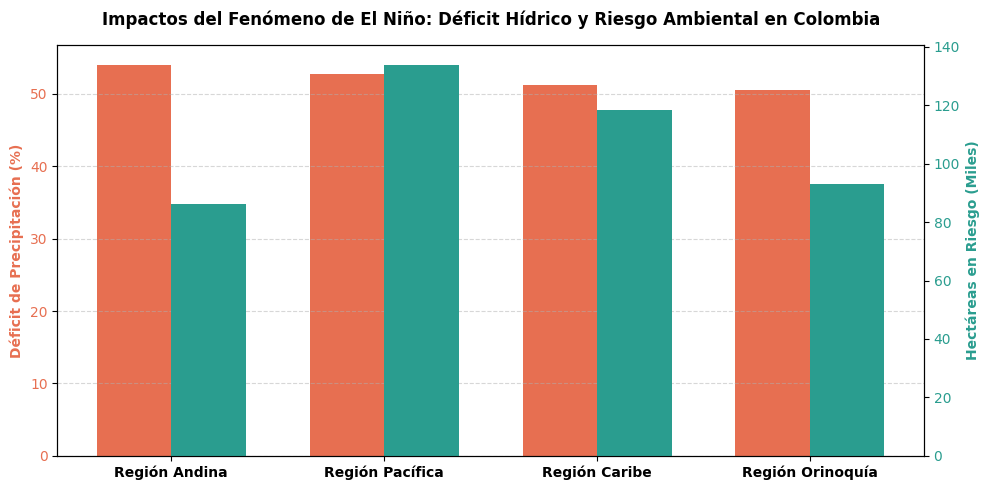

In [1]:
#Impactos del Fenómeno de El Niño en Colombia sobre los ecosistemas y la sociedad

import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. CONFIGURACIÓN Y CONEXIÓN
# ==========================================
DB_NAME = "fenomeno_nino_colombia.db"


def crear_conexion():
  """Establece y retorna la conexión a la base de datos SQLite."""
  return sqlite3.connect(DB_NAME)


# ==========================================
# 2. EXTRACCIÓN (Simulación de datos regionales con nulos)
# ==========================================
def extraer_datos_nino():
  """Genera y extrae los datos brutos de las subregiones afectadas por sequía."""
  np.random.seed(33)
  n_registros = 320
  regiones = [
      "Región Caribe",
      "Región Andina",
      "Región Orinoquía",
      "Región Pacífica",
  ]

  datos_nino = pd.DataFrame(
      {
          "id_monitoreo": [f"NINO_{i:04d}" for i in range(n_registros)],
          "region": np.random.choice(regiones, n_registros),
          "deficit_precipitacion_pct": np.random.uniform(
              15.0, 85.0, n_registros
          ).round(1),
          "indice_vulnerabilidad_social": np.random.uniform(
              1.0, 10.0, n_registros
          ).round(1),
          "riesgo_incendio_hectareas": np.random.randint(50, 2500, n_registros),
      }
  )

  # Inyectar valores nulos artificiales para probar el pipeline de limpieza
  datos_nino.loc[
      np.random.choice(n_registros, 25), "deficit_precipitacion_pct"
  ] = np.nan
  datos_nino.loc[
      np.random.choice(n_registros, 20), "riesgo_incendio_hectareas"
  ] = np.nan

  return datos_nino


# ==========================================
# 3. TRANSFORMACIÓN Y CARGA (Pipeline ETL & SQL)
# ==========================================
def transformar_y_cargar_nino(df):
  """Aplica limpieza, imputación de nulos y carga relacional en SQLite."""
  # Imputación de nulos por la mediana agrupada por región
  df["deficit_precipitacion_pct"] = df.groupby("region")[
      "deficit_precipitacion_pct"
  ].transform(lambda x: x.fillna(x.median()))
  df["riesgo_incendio_hectareas"] = df.groupby("region")[
      "riesgo_incendio_hectareas"
  ].transform(lambda x: x.fillna(x.median()))

  # Carga en base de datos relacional
  conn = crear_conexion()
  df.to_sql("impactos_nino", conn, if_exists="replace", index=False)

  query = """
        SELECT
            region,
            COUNT(id_monitoreo) AS total_registros,
            ROUND(AVG(deficit_precipitacion_pct), 2) AS prom_deficit_lluvias,
            ROUND(AVG(indice_vulnerabilidad_social), 2) AS prom_vulnerabilidad,
            ROUND(SUM(riesgo_incendio_hectareas), 0) AS total_hectareas_riesgo
        FROM impactos_nino
        GROUP BY region
        ORDER BY prom_deficit_lluvias DESC;
    """
  df_kpis = pd.read_sql(query, conn)
  conn.close()
  return df_kpis


# ==========================================
# 4. VISUALIZACIÓN DE RESULTADOS
# ==========================================
def visualizar_kpis_nino(df_kpis):
  """Genera un gráfico de doble eje para visualizar el déficit y las hectáreas en riesgo."""
  fig, ax1 = plt.subplots(figsize=(10, 5))

  x = np.arange(len(df_kpis["region"]))
  ancho = 0.35

  rects1 = ax1.bar(
      x - ancho / 2,
      df_kpis["prom_deficit_lluvias"],
      ancho,
      label="Déficit de Lluvias Promedio (%)",
      color="#e76f51",
  )
  ax1.set_ylabel(
      "Déficit de Precipitación (%)", color="#e76f51", fontweight="bold"
  )
  ax1.tick_params(axis="y", labelcolor="#e76f51")

  ax2 = ax1.twinx()
  rects2 = ax2.bar(
      x + ancho / 2,
      df_kpis["total_hectareas_riesgo"] / 1000,
      ancho,
      label="Hectáreas en Riesgo (miles)",
      color="#2a9d8f",
  )
  ax2.set_ylabel(
      "Hectáreas en Riesgo (Miles)", color="#2a9d8f", fontweight="bold"
  )
  ax2.tick_params(axis="y", labelcolor="#2a9d8f")

  ax1.set_xticks(x)
  ax1.set_xticklabels(df_kpis["region"], fontsize=10, fontweight="bold")
  ax1.set_title(
      "Impactos del Fenómeno de El Niño: Déficit Hídrico y Riesgo Ambiental en Colombia",
      fontsize=12,
      fontweight="bold",
      pad=15,
  )
  ax1.grid(axis="y", linestyle="--", alpha=0.5)

  plt.tight_layout()
  plt.show()


# Ejecución del pipeline completo
df_bruto_nino = extraer_datos_nino()
df_kpis_nino = transformar_y_cargar_nino(df_bruto_nino)
print("--- Indicadores de Impacto del Fenómeno de El Niño ---")
print(df_kpis_nino)
visualizar_kpis_nino(df_kpis_nino)